# Predicting NYC Housing Prices [Work in Progress]
# Part 2. Spatial Analysis & Feature Engineering

## Goal
Generate predictive features from clean data, with a focus on spatial dependencies and neighborhood effects.

## Inputs & Outputs
- **Input**: `data/processed/housing_cleaned.csv`
- **Output**: `data/processed/housing_with_features.csv`

## Key Steps
1. **Spatial Analysis**:
   - Moran's I calculation (Global Spatial Autocorrelation)
   - Hotspot/Coldspot identification
2. **Feature Engineering**:
   - Create `log_price` target variable
   - Broker luxury scoring
   - Property type grouping
   - (In Progress) Spatial lag features


In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

In [34]:
import geopandas as gpd

In [35]:
from sklearn.utils.parallel import Parallel, delayed

In [36]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

### Load data

In [37]:
df = pd.read_csv('../data/processed/housing_cleaned.csv')

## Exploratory Sparial Data Analysis (ESDA)

## Spatial distribution

In [38]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)

In [39]:
gdf_utm = gdf.to_crs("EPSG:32618")

<Axes: xlabel='longitude', ylabel='latitude'>

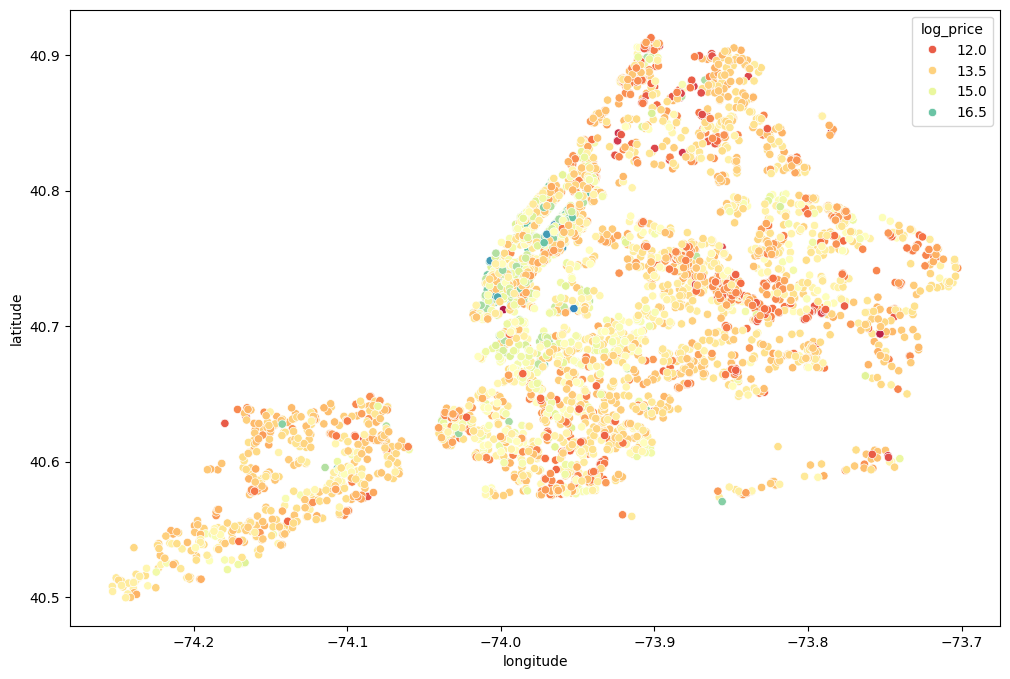

In [40]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df, palette="Spectral")

In [ ]:
gdf_utm.plot(column="log_price", 
         figsize=(12, 8),
         legend=True,
         cmap="Spectral",
         markersize=5)
plt.title("NYC Housing Prices (log scale)")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_price", data=df[df.type=='Townhouse for sale'], palette="Spectral")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_area", data=df, palette="Spectral")

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="eda_type_clean", data=df)

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="price_segment", data=df)

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="log_pps", data=df, palette="Spectral")

## Spatial distribution

In [ ]:
# Extract UTM coordinates for spatial analysis
gdf_utm['x_utm'] = gdf_utm.geometry.x
gdf_utm['y_utm'] = gdf_utm.geometry.y

In [ ]:
from libpysal.weights import DistanceBand
from esda.moran import Moran

# Spatial weights using UTM coordinates
coords = gdf_utm[['x_utm', 'y_utm']].values
w = DistanceBand.from_array(coords, threshold=1000)  # 1km threshold
moran = Moran(gdf_utm['price'], w)

In [ ]:
print(f"Moran’s I: {moran.I:.3f}, p-value: {moran.p_sim:.3f}")

# Expected Moran’s I under randomness: E[I] = -1/(n-1)
print(f"Expected I under randomness: {-1/(len(gdf_utm)-1):.3f}")

In [ ]:
gdf_manhattan = gdf_utm[gdf_utm['borough'] == 'Manhattan']
coords_manh = gdf_manhattan[['x_utm', 'y_utm']].values
w_manh = DistanceBand.from_array(coords_manh, threshold=1000)  # 1km threshold
moran_manh = Moran(gdf_manhattan['price'], w_manh)

In [ ]:
print(f"Moran’s I: {moran_manh.I:.3f}, p-value: {moran_manh.p_sim:.3f}")

# Expected Moran’s I under randomness: E[I] = -1/(n-1)
print(f"Expected I under randomness: {-1/(len(gdf_manhattan)-1):.3f}")

In [ ]:
from esda import G_Local

In [ ]:
from libpysal.weights import Kernel, DistanceBand

In [ ]:
w_kernel_final = Kernel.from_dataframe(gdf_utm, fixed=False, k=5)

In [ ]:
# Convert price to float
gdf_utm['price'] = gdf_utm['price'].astype(float)

In [ ]:
gi_final = G_Local(gdf_utm['price'], w_kernel_final, star=True)
gdf_utm['is_hotspot'] = (gi_final.Zs > 1.96).astype(int)

In [ ]:
sns.boxplot(gdf_utm, x='price', hue='is_hotspot')

In [ ]:
import folium
from folium import Marker, Circle

map = folium.Map(location=[40.75,-73.8], tiles='openstreetmap', zoom_start=11)
#for idx, row in gdf_utm[gdf_utm.is_hotspot==1].iterrows():
 #   Marker([row['latitude'], row['longitude']]).add_to(map)

def color_producer(val):
    if val == 1:
        return 'red'
    else:
        return 'grey'
    
for i in range(0,len(gdf_utm)):
    Circle(
        location= [gdf_utm.iloc[i]['latitude'], gdf_utm.iloc[i]['longitude']],
        radius=15,
        color=color_producer(gdf_utm.iloc[i]['is_hotspot'])
        ).add_to(map)
map

## Feature Engineering

In [ ]:
break

In [ ]:
# Threshold set at $3,000,000 based on central tendency analysis of the 0.90 quantile prices by property type
# And for entry - middle division set at $1,000,000
# Probable downside is that townhouses could be undervalued by modelling

# Also create cateforical price segment column for clear visual analysis (NOT SUITABLE FOR MODELLING)
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0, 1_000_000, 3_000_000, 12_000_000, np.inf],
    labels=['entry', 'mid', 'upper', 'luxury'],
    include_lowest=True,
    right=True
)

In [ ]:
sns.scatterplot(data=df, x='beds', y='bath', hue='price_segment')

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='borough', hue='price_segment')

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='price_segment')

In [ ]:
df['broker_count'] = df['brokertitle'].map(df['brokertitle'].value_counts())

In [ ]:
LUXURY_THRESHOLD = 2_000_000 

# Calculate Luxury Score for each broker
luxury_scores = (
    df[(df['price'] >= LUXURY_THRESHOLD) & (df['broker_count']>5)]  # Filter luxury properties
    .groupby('brokertitle')              # Group by broker
    .size() /                            # Count luxury listings per broker
    df.groupby('brokertitle').size()     # Divide by broker's total listings
).fillna(0)                              # Handle brokers with no luxury properties

# Add scores back to original DataFrame
df['luxury_score'] = df['brokertitle'].map(luxury_scores)

In [ ]:
df.groupby('brokertitle')[['luxury_score', 'price']].median().sort_values('luxury_score', ascending=False).head(10)

In [ ]:
peter_ashe = df[df['brokertitle'] == 'Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate']
peter_ashe['price'].describe()

In [ ]:
# Binary flags for top brokers
top_luxury_brokers = ['Garfield', 'Christie\'s', 'Sotheby\'s', 'Peter Ashe']
df['is_top_luxury_broker'] = df['brokertitle'].str.contains('|'.join(top_luxury_brokers)).astype(int)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Select broker-related features
broker_features = [
    'luxury_score',
    'broker_count',
    'is_top_luxury_broker'
]

# Train model (only on broker features for now)
X = df[broker_features]
y = df['price']  # Or log(price) if you prefer

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

In [ ]:
importances = pd.Series(model.feature_importances_, index=broker_features).sort_values()
importances.plot(kind='barh', title='Broker Feature Importance')

In [ ]:
df[['luxury_score', 'price']].corr()

In [ ]:
df.brokertitle.value_counts().describe()

In [ ]:
# In previous attemnt I write "High cardinality variable, it looks like it's not going to be helpfull"
# But now I think I am going to use brokers data in some form on modelling
# Probably wiil TARGET ENCODE broker luxury score on train data

In [ ]:
# Create dummy variables based on type_clean
type_dummies = pd.get_dummies(
    df['eda_type_clean'],
    prefix='type',
    drop_first=True,  # Avoids dummy variable trap
    dtype=int         # Saves memory vs bool
)

# join back to original DataFrame
df = pd.concat([df, type_dummies], axis=1)

In [ ]:
# Create the upper segment flag
df['is_upper'] = (df['price'] > 3_000_000).astype(int)

# Also add middle segment more then 1 mln and lower then upper segment
df['is_mid'] = ((df['price'] > 1_000_000) & (df['price'] <= 3_000_000)).astype(int)

df['is_luxury'] = (df['price'] > 12_000_000).astype(int)

In [ ]:
# Flag properties with >12 bedrooms
df['is_high_beds'] = (df['beds'] > 12).astype(int)

In [ ]:
# IDEA: Probably could do Frequency Encoding on beds or one hot encoding on beds_binned

In [ ]:
## Save feature engineered data

In [ ]:
# Prepare final export
drop_cols = ['price_segment', 'is_upper', 'is_mid', 'is_luxury', 
             'coldspot_zip', 'zip_median_price'] # Remove leakage
final_df = df.drop(columns=drop_cols, errors='ignore')

# Note on luxury_score: Currently calculated on full data (leakage risk).
# Better to re-calculate in Notebook 3 using K-Fold Target Encoding pipeline.
# For now, we will keep it but marked as 'risky_feature' in your mind.

final_df.to_csv('../data/processed/housing_with_features.csv', index=False)